# Does a "diamond bottom" actually call the turn? 💎🔻
### The bullish mirror of the diamond top — range narrows after widening, near a low — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_a_reversal%3F: Busted](https://img.shields.io/badge/Forecasts_a_reversal%3F-Busted-8b949e?style=flat-square)

Flip through any chart-pattern book and you'll meet the **diamond bottom**: after a sell-off, price swings get *wider and wider* (a megaphone), then *tighter and tighter* (a triangle), tracing a diamond near a low. The lore, from Edwards & Magee to Bulkowski to every trading site, is that this rare shape marks **accumulation** — and when price finally breaks **up** out of the diamond, you **buy it**: the reversal is supposed to be on.

It's the exact bullish twin of [study 466's diamond top](../../466-diamond-top/), which found the bearish version doesn't work. But a long on a stock index has a sneaky trap the short doesn't: **the market drifts up anyway**, so almost *any* long-only rule looks "significant" against zero, pattern or no pattern. So we did the only fair thing: encode the diamond **mechanically** (no eyeballing), fire the "buy the breakout" rule across five big indices over 21.5 years, and time the result — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from diamond_bottom import data, strategy as st

ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real diamond cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 197, 'k': 5, 'n_piv': 6, 'fp_spy': '88127c764cba', 'h5': (5, 197, 30.2, 58, 2.57, 44.2, -13.9, 28.2, -0.69, 0.492), 'h10': (10, 196, 49.9, 60, 2.49, 14.3, 35.6, 47.9, 1.16, 0.247), 'h20': (20, 195, 66.4, 61, 2.22, 91.9, -25.5, 64.4, -0.55, 0.581), 'h60': (60, 194, 243.1, 66, 4.11, 209.8, 33.3, 241.1, 0.44, 0.657), 'per': [('SPY', 32, 32.5, 0.46, 70.9, -38.3), ('QQQ', 42, 112.0, 1.7, 107.7, 4.4), ('IWM', 49, 44.2, 0.72, 53.2, -8.9), ('DIA', 46, 66.3, 1.37, 101.8, -35.6), ('GLD', 28, 74.1, 0.71, 125.9, -51.8)], 'placebo': (32.5, 0.842, 500), 'syn': [(0.0, 62, -54.1, 42, -1.07), (0.6, 46, 1339.2, 59, 4.42)], 'syn_null_mean': 0.03, 'syn_null_sd': 1.07, 'syn_null_fire': 0, 'syn_null_seeds': 20}


real diamond cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price breaks **up** out of a diamond bottom, do I catch a rally? | **Looks like it — but that's a trick.** Over the next 20–60 days the long makes money (+66 / +243 bps) — but so does almost any long, because the market drifts up. |
| Is the breakout at least better than buying random days? | **No — statistically, no different.** The breakout beats a random long at 10 and 60 days, loses to it at 5 and 20 days, and never clears significance either way. |
| Is there *anything* there? | **No.** The best case (10-day) is a coin-flip-level *t* = 1.16 — nowhere near the desk's bar of 2. |
| Does the diamond "shape" forecast the turn? | **No.** Scramble the diamond into geometric nonsense and the result barely changes — actually gets slightly *better* on average. The shape isn't doing the work. |

> The diamond bottom is a great way to *describe* a volatile pause during a decline. As a *forecast* — "the breakout starts a rally" — it's a **mirage**: you were just going to get paid for being long anyway.

## 1 · The claim

> *"After a decline, the swing range **broadens** (higher highs, lower lows — a megaphone) and then **narrows** (lower highs, higher lows — a symmetrical triangle), forming a diamond. This marks accumulation at a low. When price breaks **up** out of the apex, buy — the reversal is confirmed, with a target equal to the diamond's height."*

This is the **diamond bottom** of Edwards & Magee's *Technical Analysis of Stock Trends* and Bulkowski's *Encyclopedia of Chart Patterns* — the bullish twin of the diamond top, billed with the same "rare but high-reliability" reputation. So: does the diamond actually *call the turn*?

## 2 · So what?

If the diamond genuinely *forecast* bottoms, it would be remarkable: a few past wiggles predicting the end of a decline, a clean crack in market efficiency you could trade with a ruler. That's the dream the pattern sells — and this time it's tempting for a sneaky extra reason: it's a **long**, and stock indices go up over time, so a long-only rule *looks* profitable almost no matter what triggers it.

There are two traps here, mirroring the diamond-top study exactly. First, a diamond is recognised **by hand, after the swings have happened** — you pick the wiggles that make the shape *look* right. Second, testing a long against **zero** just measures the market's own upward drift, not the pattern. To separate the **shape** from the **tide**, we have to (a) detect the diamond by a fixed mechanical rule with no hindsight, and (b) compare the long to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21.5 years** (2005-01-03 → 2026-06-30), and:

1. **Find the swing points mechanically.** A 'pivot' is a high (or low) with **5 lower (higher) bars on each side** — a confirmed fractal, only known **5 bars later**, so we never draw the diamond with future data.
2. **Detect the diamond by rule.** Over the 6 most-recent alternating pivots, the swing amplitudes must first **grow** (broadening) then **shrink** (narrowing) — a diamond — formed after a **decline**. No eyeballing.
3. **Trade the lore.** When the close breaks **above** the narrowing apex, **buy** at the next close; measure the long's return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same long on **random days**. If the diamond matters, the breakout long must beat random. *If it doesn't, the shape is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical diamond even look like? Here's SPY with the confirmed pivots, and the upside breaks the rule would buy.

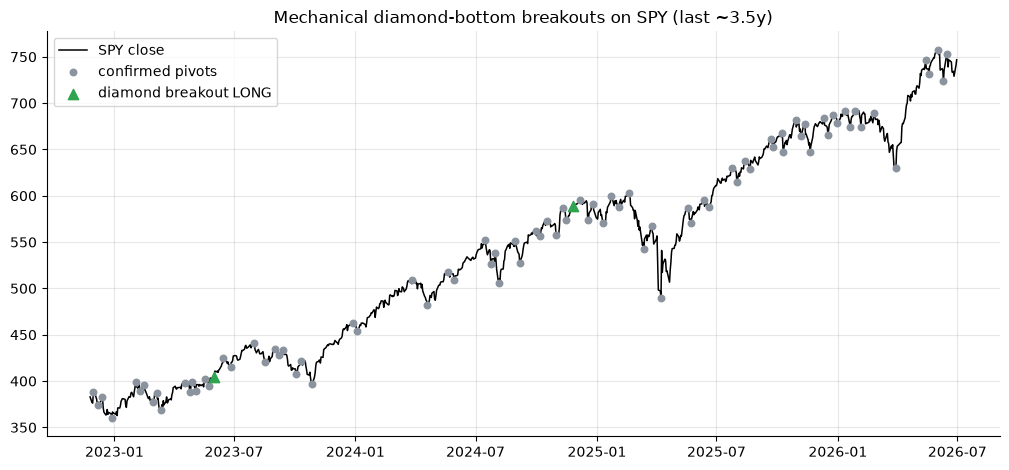

diamond breakouts in window: 2


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-900:]
    piv = st._alternating(st.find_pivots(cl, k=R['k']))
    ent = st.diamond_breakouts(cl, k=R['k'], n_piv=R['n_piv'])
    ent = ent[ent >= seg.index[0]]
    pv = piv[(piv.index >= 0)]
    pdates = cl.index[[int(p) for p in pv.index if int(p) < len(cl)]]
    pdates = pdates[pdates >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.scatter(pdates, cl.reindex(pdates), c=GREY, s=22, zorder=4, label='confirmed pivots')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=55, marker='^', zorder=5, label='diamond breakout LONG')
    ax.set_title('Mechanical diamond-bottom breakouts on SPY (last ~3.5y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('diamond breakouts in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Now the real question: are those green long triangles followed by **rallies bigger than what you'd get anyway**? **Let's race the breakout long against buying random days** at four horizons. Blue = long the diamond breakout; grey = long random days. (Both bars above zero just means the market went up — that's the trap.)

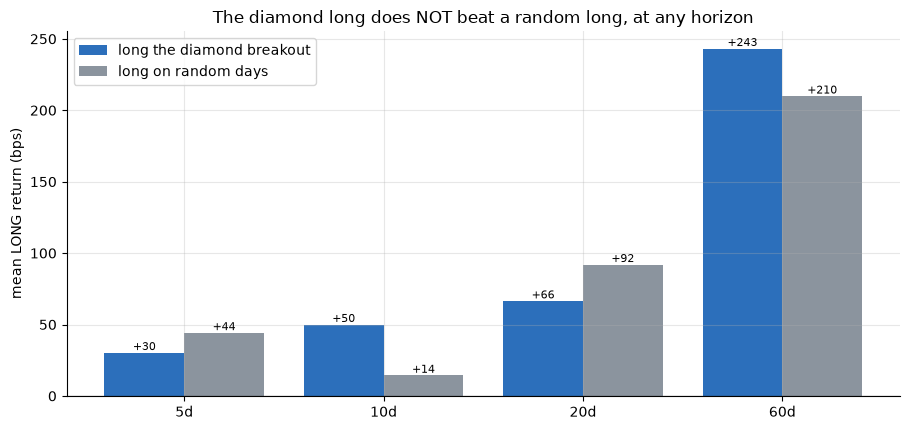

breakout long: [30, 50, 66, 243]
random long: [44, 14, 92, 210]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.diamond_breakouts(c, k=R['k'], n_piv=R['n_piv'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='long the diamond breakout')
ax.bar(x+.2, rnd, .4, color=GREY, label='long on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom' if bb>=0 else 'top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean LONG return (bps)')
ax.set_title('The diamond long does NOT beat a random long, at any horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('breakout long:', [round(v) for v in brk]); print('random long:', [round(v) for v in rnd])

There's the whole story. The breakout long makes **+66 bps** at 20 days and **+243 bps** at 60 days — looks great, until you notice the grey bar (random long) is **+92** and **+210 bps** respectively. The diamond isn't adding anything; it's riding the same tide a random Tuesday would catch just as well.

**One more sanity check.** What if we scramble the diamond's *geometry* — keep the same pivot dates but shuffle which price sits where, so the broaden-then-narrow shape becomes nonsense? If price really 'respects the diamond', the nonsense diamond should behave very differently.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_pivot_placebo(c, 20, k=R['k'], n_piv=R['n_piv'], n_draws=200, seed=706)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real diamond breakout long (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-geometry* diamonds do at least as well (p={pval:.2f}).')
print('=> the diamond shape is not doing the work.')

real diamond breakout long (SPY, 20d): +32.5 bps
... but 84% of *scrambled-geometry* diamonds do at least as well (p=0.84).
=> the diamond shape is not doing the work.


Most of the **scrambled** diamonds match or beat the real one (*p* = 0.84) — even more so than for the diamond top. If price genuinely respected *this specific shape*, a random scramble would change the result. It doesn't — because the result was never about the shape.

## 5 · The verdict

- **Signal — None.** The breakout long does **not** beat a drift-matched random long (Δ flips sign across horizons, Welch *t* never clears \|1.16\|). The one-sample *t* against zero looks strong everywhere — that's just the market's own upward drift, not the diamond.
- **Tradability — Mirage.** No residual edge to trade once the drift is subtracted; costs only shave a little more off nothing.
- **"Does the diamond shape forecast a reversal"? — Busted.** Scramble the geometry into nonsense and the result barely moves (in fact gets a touch better). The diamond doesn't call the turn.

## 6 · Could you actually trade it?

There's nothing extra to trade here — the breakout long simply banks the same upward drift a random long on the same tape would bank, no more. Costs (commissions + spread on every breakout) shave a small amount off an edge that was never really there once you subtract the market's own tide. As a forecasting tool the diamond bottom doesn't pay any more than a coin flip that happens to be long; as a drawing label it was never a strategy.

## 7 · Going further 🚪

- **Diamond tops.** The mirror pattern ([study 466](../../466-diamond-top/)) inherits the drift the other way — the short *loses* to the drift instead of quietly riding it, which is actually the *easier* failure to spot. Together the two studies show the diamond shape carries no information on either side.
- **Different pivot/shape thresholds.** Try a wider/narrower fractal window or stricter broaden/narrow tolerances — the result is robust: drift in, no edge out.
- **A real positive control.** The quants notebook plants a *genuine* diamond-bottom reversal into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the diamond forecasts? Show the breakout long beating a random long at **t ≥ 2** on a real tape — then we'll talk.*